In [2]:
from unsloth import FastVisionModel
import torch

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


/home/pcw/finetune/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [3]:
model, processor = FastVisionModel.from_pretrained(
    "unsloth/gemma-4-E2B-it",
    load_in_4bit = True,
    use_gradient_checkpointing = True,
)


==((====))==  Unsloth 2026.4.5: Fast Gemma4 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA GeForce RTX 5090. Num GPUs = 1. Max memory: 31.357 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 12.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights: 100%|██████████| 2011/2011 [00:14<00:00, 142.65it/s]


## model parameter
- model: 選用微調的模型
- finetune_vision_layers: 允許微調模型中視覺處理
- finetune_language_layers: 允許微調模型中語言處理
- finetune_attention_modules: 允許微調注意力機制
- finetune_mlp_modules: 允許微調多層感知機
- r: LoRA 矩陣的大小，較高的 r 可以存儲更多資訊
- lora_alpha: 控制 LoRA 更新的影響力
- lora_dropout: 設置 dropout 以防止 overfining
- bias: LoRA 層中加入 bias
- use_rslora: Rank Stabilized LoRA，讓 LoRA 訓練更穩定
- loftq_config: Low-rank Fine-Tuning with Quantization，讓 LoRA 訓練更穩定
- target_modules: 要微調的模型層

In [4]:
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers = True,
    finetune_language_layers = True,
    finetune_attention_modules = True,
    finetune_mlp_modules = True,
    
    r = 32,
    lora_alpha = 32,
    lora_dropout = 0,
    bias = "none",
    use_rslora = False,
    loftq_config = None,
    target_modules = "all-linear",
    seed = 0,
)

## Dataset Setting

In [5]:
from datasets import load_dataset
from datasets import Dataset

dataset = load_dataset("unsloth/LaTeX_OCR", split="train") # 下載 Train dataset
split = dataset.train_test_split(test_size=0.0015, seed=0) # 將 Train dataset 分割成 Train 和 Test dataset
test_samples = split["test"] # 0.15%
train_samples = split["train"] # 99.85%

dataset

Dataset({
    features: ['image', 'text'],
    num_rows: 68686
})

## Prompting and Converting

In [6]:
# 任務提示詞
instruction = "Write the LaTeX representation for this image." 

# 將資料轉換成對話格式
def convert_to_conversation(sample):
    conversation = [
        {
            "role": "user", # 問題
            "content": [
                {"type": "text", "text": instruction}, # 任務提示詞
                {"type": "image", "image": sample["image"]}, # 圖片
            ],
        },
        {
            "role": "assistant", # 答案
            "content": [
                {"type": "text", "text": sample["text"]} # LaTeX 表示
            ]
        }, 
    ]
    return {"messages": conversation}
pass


converted_dataset = [convert_to_conversation(sample) for sample in train_samples] # 將 Train dataset 轉換成對話格式
converted_testset = [convert_to_conversation(s) for s in test_samples] # 將 Test dataset 轉換成對話格式


In [7]:
from unsloth import get_chat_template

processor = get_chat_template(
    processor,
    "gemma-4"
)

##  Training

In [8]:
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig

## Trainer
- model: 選用微調的模型
- train_dataset: 訓練的資料
- data_collator: 批次組裝器
- SFTConfig:
    - per_device_train_batch_size: 每次 GPU 一次處理張數
    - max_steps: 總共訓練的步數
    - learing_rate: 控制模型在每步更新權重的幅度
    - optim: 指定優化器
    - remove_unused_columns: 控制自動刪掉資料集中未使用的欄位
    - dataset_text_field: 指定資料集中哪個欄位包含文字
    - dataset_kwargs: 傳遞額外的資料集設定
    - max_length: 輸入序列的最大長度


In [9]:
trainer = SFTTrainer(
    model = model,
    train_dataset = converted_dataset,
    eval_dataset = converted_testset,
    data_collator = UnslothVisionDataCollator(model, processor),
    
    args = SFTConfig(
        per_device_train_batch_size = 1,
        gradient_accumulation_steps = 2,
        max_steps = 500,
        
        eval_strategy = "steps",
        eval_steps = 10,
        per_device_eval_batch_size = 5,
        learning_rate = 2e-4,
        optim = "adamw_8bit",

        remove_unused_columns = False,
        dataset_text_field = "",
        dataset_kwargs = {"skip_prepare_dataset": True},
        max_length = 2048,

        seed = 0,
    )
)


Unsloth: Model does not have a default image size - using 512


## Accuracy Evaluation


In [10]:
import torch
from tqdm import tqdm

def evaluate_accuracy(model, processor, samples, max_new_tokens=256):
    FastVisionModel.for_inference(model)
    exact = 0
    char_correct, char_total = 0, 0
    total = 0

    for s in tqdm(samples):
        image = s["image"]
        gt = s["text"].strip()

        messages = [{"role": "user", "content": [
            {"type": "image"},
            {"type": "text", "text": "Write the LaTeX representation for this image."},
        ]}]
        text = processor.apply_chat_template(messages, add_generation_prompt=True)
        inputs = processor(image, text, add_special_tokens=False, return_tensors="pt").to("cuda")

        with torch.no_grad():
            out = model.generate(**inputs, max_new_tokens=max_new_tokens,
                                 use_cache=True, do_sample=False)
        pred = processor.decode(out[0, inputs["input_ids"].shape[1]:],
                                skip_special_tokens=True).strip()

        if pred == gt:
            exact += 1
        m = min(len(pred), len(gt))
        char_correct += sum(1 for i in range(m) if pred[i] == gt[i])
        char_total += max(len(pred), len(gt), 1)
        total += 1

    return {"exact_match": exact / total, "char_accuracy": char_correct / char_total}


In [11]:
FastVisionModel.for_inference(model)
acc_before = evaluate_accuracy(model, processor, test_samples)

100%|██████████| 104/104 [04:47<00:00,  2.76s/it]


In [12]:
train_results = trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': 2}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 68,582 | Num Epochs = 1 | Total steps = 500
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 2 x 1) = 2
 "-____-"     Trainable parameters = 59,719,680 of 5,182,897,696 (1.15% trained)
Caching is incompatible with gradient checkpointing in Gemma4TextDecoderLayer. Setting `past_key_values=None`.


Step,Training Loss,Validation Loss
10,10.424274,3.435470
20,4.343526,3.298013


In [13]:
model.save_pretrained("gemma_4_lora")
processor.save_pretrained("gemma_4_lora")

['gemma_4_lora/processor_config.json']

# Visualize

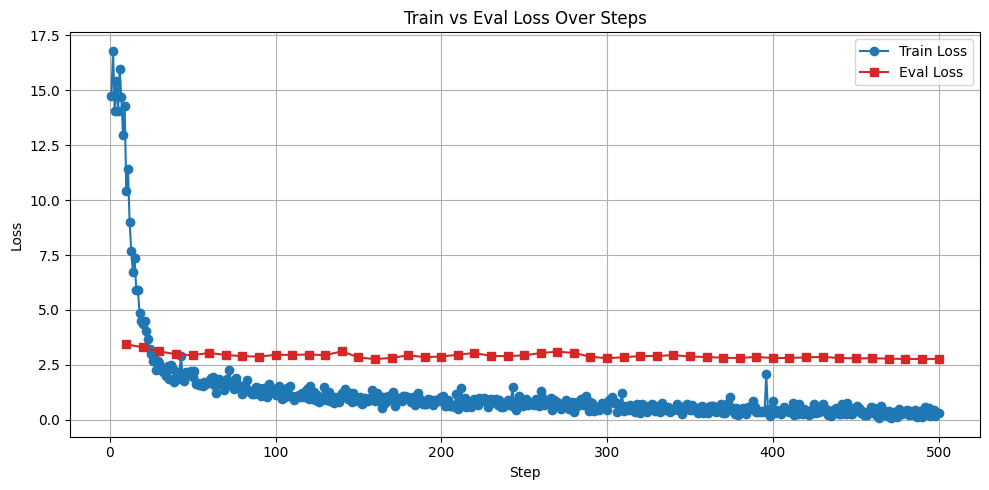

In [14]:
import matplotlib.pyplot as plt

logs = trainer.state.log_history

train_steps  = [x["step"] for x in logs if "loss" in x and "eval_loss" not in x]
train_losses = [x["loss"] for x in logs if "loss" in x and "eval_loss" not in x]

eval_steps   = [x["step"]      for x in logs if "eval_loss" in x]
eval_losses  = [x["eval_loss"] for x in logs if "eval_loss" in x]

plt.figure(figsize=(10, 5))
plt.plot(train_steps, train_losses, marker="o", label="Train Loss")
plt.plot(eval_steps,  eval_losses,  marker="s", label="Eval Loss", color="tab:red")
plt.title("Train vs Eval Loss Over Steps")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig("loss_curve.png", dpi=150)
plt.show()


In [15]:
FastVisionModel.for_inference(model)
acc_after = evaluate_accuracy(model, processor, test_samples)

  8%|▊         | 8/104 [00:22<04:27,  2.79s/it]

100%|██████████| 104/104 [04:03<00:00,  2.34s/it]


In [16]:
print("Before fine-tune:", acc_before)
print("After  fine-tune:", acc_after)

Before fine-tune: {'exact_match': 0.0, 'char_accuracy': 0.045103399096743525}
After  fine-tune: {'exact_match': 0.0, 'char_accuracy': 0.0711275699144426}
